In [2]:
import pandas as pd

df = pd.read_csv("../data/Titanic_cleaned.csv") 
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

CV ROC-AUC scores:
LogisticRegression: 0.8564
RandomForest: 0.8463
KNN: 0.8407

Best model selected: LogisticRegression
Validation Accuracy: 0.8044692737430168
Validation ROC-AUC: 0.8868725868725869


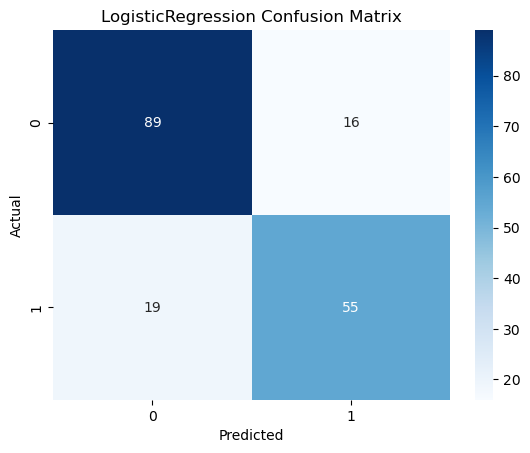

Best pipeline saved to models/best_pipeline.joblib


In [15]:
# 1. Import Libraries

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


# 3. Train/Validation Split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


# 4. Define ColumnTransformer

numeric_features = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'IsAlone', 'Title_Mr', 'Title_Mrs', 'Title_Rare',
                        'Embarked_Q', 'Embarked_S', 'AgeGroup_Teen', 'AgeGroup_Adult',
                        'AgeGroup_Middle', 'AgeGroup_Senior', 'FareBand']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', categorical_features)  # already 0/1
    ]
)


# 5. Define Pipelines

pipe_lr = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

pipe_rf = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe_knn = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=7))
])

pipelines = {'LogisticRegression': pipe_lr, 'RandomForest': pipe_rf, 'KNN': pipe_knn}


# 6. Cross-Validation for Model Selection

cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
    cv_results[name] = np.mean(scores)

print("CV ROC-AUC scores:")
for name, score in cv_results.items():
    print(f"{name}: {score:.4f}")

# Pick the best pipeline

best_model_name = max(cv_results, key=cv_results.get)
best_pipeline = pipelines[best_model_name]
print("\nBest model selected:", best_model_name)


# 7. Train Best Pipeline on Full Training Set

best_pipeline.fit(X_train, y_train)


# 8. Evaluate on Validation Set

y_pred = best_pipeline.predict(X_val)
y_prob = best_pipeline.predict_proba(X_val)[:, 1]

print("Validation Accuracy:", accuracy_score(y_val, y_pred))
print("Validation ROC-AUC:", roc_auc_score(y_val, y_prob))

# Confusion matrix

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"{best_model_name} Confusion Matrix")
plt.show()


# 9. Export Best Pipeline

joblib.dump(best_pipeline, "../models/best_pipeline.joblib")
print("Best pipeline saved to models/best_pipeline.joblib")
